# Notebook 3: Explainability, Confidence Analysis, and Deployment-Ready Ticket Routing Outputs

## Project
**Automating Support Ticket Routing with NLP**

## Notebook objective
This notebook extends the baseline support ticket routing model by focusing on interpretability, prediction confidence, human-review fallback rules, and operational outputs.

## Why this notebook matters
A high-performing classifier is useful, but production-ready support automation also requires:
- understandable predictions
- visibility into model confidence
- a review path for uncertain tickets
- practical outputs that can support downstream triage workflows

This notebook therefore moves beyond accuracy and focuses on how the model can be used more responsibly and operationally.

## Main goals
This notebook will:
- load the trained routing pipeline
- generate predictions and confidence-aware outputs
- inspect class-specific vocabulary and influential terms
- review low-confidence cases
- analyse misclassifications where available
- simulate a human-review fallback process
- prepare prediction outputs suitable for a dashboard or Streamlit app

## Important note
If the synthetic dataset is highly separable, the model may achieve unrealistically strong performance. In such a case, this notebook is still valuable because it helps identify:
- whether predictions are overly easy
- whether confidence is uniformly high
- whether the dataset may need to be made more realistic

In [21]:
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

SEED = 42
np.random.seed(SEED)

## Load the cleaned dataset and trained pipeline

We load:
- the cleaned dataset created in Notebook 1
- the saved best pipeline produced in Notebook 2

The saved pipeline already includes:
- the TF-IDF vectorizer
- the trained classification model

In [22]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

clean_path = PROCESSED_DIR / "support_tickets_clean.csv"
model_path = MODELS_DIR / "best_ticket_routing_pipeline.joblib"

df = pd.read_csv(clean_path)
pipeline = joblib.load(model_path)

print("Loaded dataset:", clean_path)
print("Loaded model:", model_path)
print("Dataset shape:", df.shape)

Loaded dataset: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\data\processed\support_tickets_clean.csv
Loaded model: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\models\best_ticket_routing_pipeline.joblib
Dataset shape: (3684, 15)


## Recreate the evaluation dataset

To keep this notebook aligned with Notebook 2, we recreate the same train-test split using the same random seed.

This allows us to:
- reproduce the same held-out test set
- inspect model behaviour on unseen tickets
- build explainability outputs on the same evaluation data

In [23]:
from sklearn.model_selection import train_test_split

model_df = df[["ticket_text", "routed_team"]].copy()
model_df["ticket_text"] = model_df["ticket_text"].fillna("").astype(str).str.strip()
model_df["routed_team"] = model_df["routed_team"].astype(str).str.strip()
model_df = model_df[model_df["ticket_text"].str.len() > 0].copy()

X = model_df["ticket_text"]
y = model_df["routed_team"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 2947
Test size: 737


## Generate baseline predictions on the test set

We generate predictions for the held-out test set and store them in a structured table for further analysis.

In [24]:
y_pred = pipeline.predict(X_test)

predictions_df = pd.DataFrame({
    "ticket_text": X_test.values,
    "actual_team": y_test.values,
    "predicted_team": y_pred
})

predictions_df["is_correct"] = predictions_df["actual_team"] == predictions_df["predicted_team"]

print("Prediction sample:")
display(predictions_df.head())

Prediction sample:


,ticket_text,actual_team,predicted_team,is_correct
0,"Can someone help Hello, I cannot complete the workflow because something keeps breaking. It involves api on my side. I need this resolved as soon as possibl...",Technical Support,Technical Support,True
1,"Help needed I want to understand the pricing options better. It involves invoice portal on my side. In addition, the system keeps showing an error when I tr...",Product Inquiry,Product Inquiry,True
2,Problem with recent activity I need help with something. I want to understand the pricing options better. I do not know if this should go to billing or supp...,Product Inquiry,Product Inquiry,True
3,Need an update on this issue The package is missing and I need an update. I only need a clear update on what is happening.,Orders & Delivery,Orders & Delivery,True
4,Follow-up on my previous issue I cannot sign in to my account at the moment. It involves web app on my side.,Account Access,Account Access,True


## Compute prediction confidence scores where supported

Some classifiers support:
- `predict_proba()` directly, or
- `decision_function()` scores that can be converted into relative confidence indicators

This notebook attempts confidence extraction automatically.

### Why confidence matters
Confidence is useful because it allows the workflow to:
- auto-route high-confidence tickets
- flag uncertain tickets for manual review
- reduce risk when the model is unsure

In [25]:
def softmax(x, axis=1):
    x = np.asarray(x)
    x_max = np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)

def get_confidence_scores(fitted_pipeline, X_input):
    model = fitted_pipeline.named_steps["model"]

    if hasattr(fitted_pipeline, "predict_proba"):
        probs = fitted_pipeline.predict_proba(X_input)
        pred_idx = np.argmax(probs, axis=1)
        confidence = probs[np.arange(len(pred_idx)), pred_idx]
        labels = fitted_pipeline.classes_[pred_idx] if hasattr(fitted_pipeline, "classes_") else fitted_pipeline.predict(X_input)
        return {
            "method": "predict_proba",
            "confidence": confidence,
            "all_scores": probs,
            "predicted_labels": labels
        }

    if hasattr(model, "predict_proba"):
        X_vec = fitted_pipeline.named_steps["tfidf"].transform(X_input)
        probs = model.predict_proba(X_vec)
        pred_idx = np.argmax(probs, axis=1)
        confidence = probs[np.arange(len(pred_idx)), pred_idx]
        labels = model.classes_[pred_idx]
        return {
            "method": "predict_proba",
            "confidence": confidence,
            "all_scores": probs,
            "predicted_labels": labels
        }

    if hasattr(model, "decision_function"):
        X_vec = fitted_pipeline.named_steps["tfidf"].transform(X_input)
        decision = model.decision_function(X_vec)

        if decision.ndim == 1:
            decision = np.column_stack([-decision, decision])

        pseudo_probs = softmax(decision, axis=1)
        pred_idx = np.argmax(pseudo_probs, axis=1)
        confidence = pseudo_probs[np.arange(len(pred_idx)), pred_idx]
        labels = model.classes_[pred_idx]
        return {
            "method": "decision_function_softmax",
            "confidence": confidence,
            "all_scores": pseudo_probs,
            "predicted_labels": labels
        }

    return {
        "method": "not_available",
        "confidence": np.array([np.nan] * len(X_input)),
        "all_scores": None,
        "predicted_labels": fitted_pipeline.predict(X_input)
    }

confidence_output = get_confidence_scores(pipeline, X_test)

predictions_df["predicted_team"] = confidence_output["predicted_labels"]
predictions_df["confidence_score"] = confidence_output["confidence"]

print("Confidence method used:", confidence_output["method"])
display(predictions_df.head())

Confidence method used: decision_function_softmax


,ticket_text,actual_team,predicted_team,is_correct,confidence_score
0,"Can someone help Hello, I cannot complete the workflow because something keeps breaking. It involves api on my side. I need this resolved as soon as possibl...",Technical Support,Technical Support,True,0.757888
1,"Help needed I want to understand the pricing options better. It involves invoice portal on my side. In addition, the system keeps showing an error when I tr...",Product Inquiry,Product Inquiry,True,0.443316
2,Problem with recent activity I need help with something. I want to understand the pricing options better. I do not know if this should go to billing or supp...,Product Inquiry,Product Inquiry,True,0.578294
3,Need an update on this issue The package is missing and I need an update. I only need a clear update on what is happening.,Orders & Delivery,Orders & Delivery,True,0.554919
4,Follow-up on my previous issue I cannot sign in to my account at the moment. It involves web app on my side.,Account Access,Account Access,True,0.782033


## Summarise confidence behaviour

This section helps answer questions such as:
- Is the model consistently confident?
- Are incorrect predictions less confident than correct ones?
- Are there tickets that should be reviewed by a human before routing?

In [26]:
print("Confidence summary:")
display(predictions_df["confidence_score"].describe())

confidence_by_correctness = (
    predictions_df.groupby("is_correct")["confidence_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

print("\nConfidence by correctness:")
display(confidence_by_correctness)

Confidence summary:


count    737.000000
mean       0.585432
std        0.132705
min        0.192831
25%        0.500378
50%        0.589340
75%        0.678213
max        0.910433
Name: confidence_score, dtype: float64


Confidence by correctness:


,count,mean,median,min,max
is_correct,,,,,
False,28,0.3468,0.3517,0.1928,0.5493
True,709,0.5949,0.5939,0.2094,0.9104


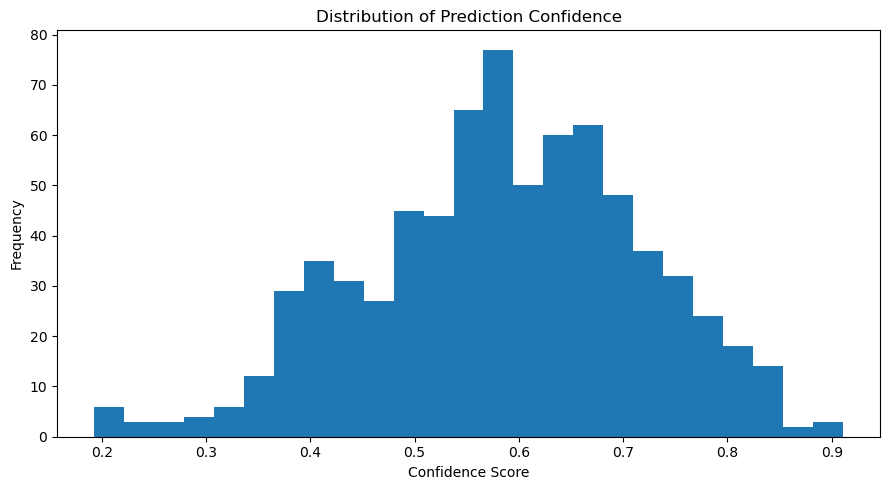

Saved figure to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\figures\confidence_distribution.png


In [27]:
plt.figure(figsize=(9, 5))
plt.hist(predictions_df["confidence_score"].dropna(), bins=25)
plt.title("Distribution of Prediction Confidence")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.tight_layout()

confidence_dist_path = FIGURES_DIR / "confidence_distribution.png"
plt.savefig(confidence_dist_path, dpi=200)
plt.show()

print("Saved figure to:", confidence_dist_path)

## Apply a human-review fallback rule



In [28]:
REVIEW_THRESHOLD = 0.80

predictions_df["routing_decision"] = np.where(
    predictions_df["confidence_score"] >= REVIEW_THRESHOLD,
    "Auto-route",
    "Human review"
)

decision_summary = predictions_df["routing_decision"].value_counts().rename_axis("decision").reset_index(name="count")
decision_summary["percentage"] = (decision_summary["count"] / len(predictions_df) * 100).round(2)

print("Routing decision summary:")
display(decision_summary)

Routing decision summary:


,decision,count,percentage
0,Human review,703,95.39
1,Auto-route,34,4.61


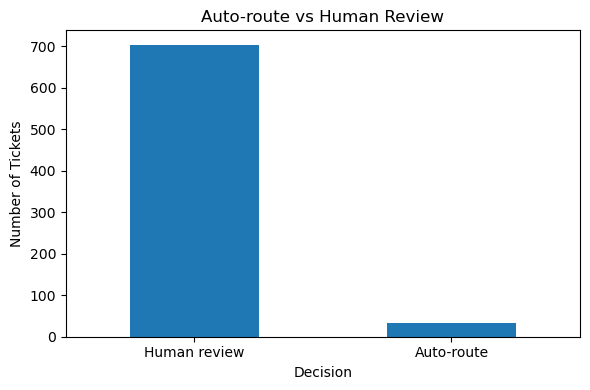

Saved figure to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\figures\auto_route_vs_review.png


In [29]:
plt.figure(figsize=(6, 4))
predictions_df["routing_decision"].value_counts().plot(kind="bar")
plt.title("Auto-route vs Human Review")
plt.xlabel("Decision")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()

decision_path = FIGURES_DIR / "auto_route_vs_review.png"
plt.savefig(decision_path, dpi=200)
plt.show()

print("Saved figure to:", decision_path)

## Inspect low-confidence tickets


In [30]:
low_confidence_df = predictions_df.sort_values("confidence_score", ascending=True).copy()

print("Lowest-confidence tickets:")
display(low_confidence_df.head(15).reset_index(drop=True))

Lowest-confidence tickets:


,ticket_text,actual_team,predicted_team,is_correct,confidence_score,routing_decision
0,Follow-up on my previous issue,Billing,Account Access,False,0.192831,Human review
1,Follow-up on my previous issue,Billing,Account Access,False,0.192831,Human review
2,Issue not resolved,Billing,Account Access,False,0.198077,Human review
3,NEED AN UPDATE ON THIS ISSUE,Orders & Delivery,Product Inquiry,False,0.209353,Human review
4,Need an update on this issue,Product Inquiry,Product Inquiry,True,0.209353,Human review
5,isue with recent order,Refunds & Returns,Refunds & Returns,True,0.214881,Human review
6,Support request still,Account Access,Billing,False,0.224344,Human review
7,Problem with recent activity,Technical Support,Product Inquiry,False,0.228637,Human review
8,PLEASE REVIEW THIS REQUEST,Orders & Delivery,Billing,False,0.236504,Human review
9,crash on my account,Technical Support,Technical Support,True,0.252599,Human review


## Evaluate model performance again with a classification report

This provides a class-level view of:
- precision
- recall
- F1-score
- support

If performance is unrealistically perfect, this may suggest that the synthetic data is too easy or too separable.

In [31]:
report_df = pd.DataFrame(
    classification_report(y_test, predictions_df["predicted_team"], output_dict=True)
).transpose().round(4)

display(report_df)

report_path = RESULTS_DIR / "notebook3_classification_report.csv"
report_df.to_csv(report_path)

print("Saved report to:", report_path)

,precision,recall,f1-score,support
Account Access,0.9369,0.9630,0.9498,108.000
Billing,0.9280,0.9667,0.9469,120.000
Orders & Delivery,0.9908,0.9730,0.9818,111.000
Product Inquiry,0.9429,0.9706,0.9565,102.000
Refunds & Returns,0.9912,0.9573,0.9739,117.000
Technical Support,0.9770,0.9497,0.9632,179.000
accuracy,0.9620,0.9620,0.9620,0.962
macro avg,0.9611,0.9634,0.9620,737.000
weighted avg,0.9628,0.9620,0.9622,737.000


Saved report to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\notebook3_classification_report.csv


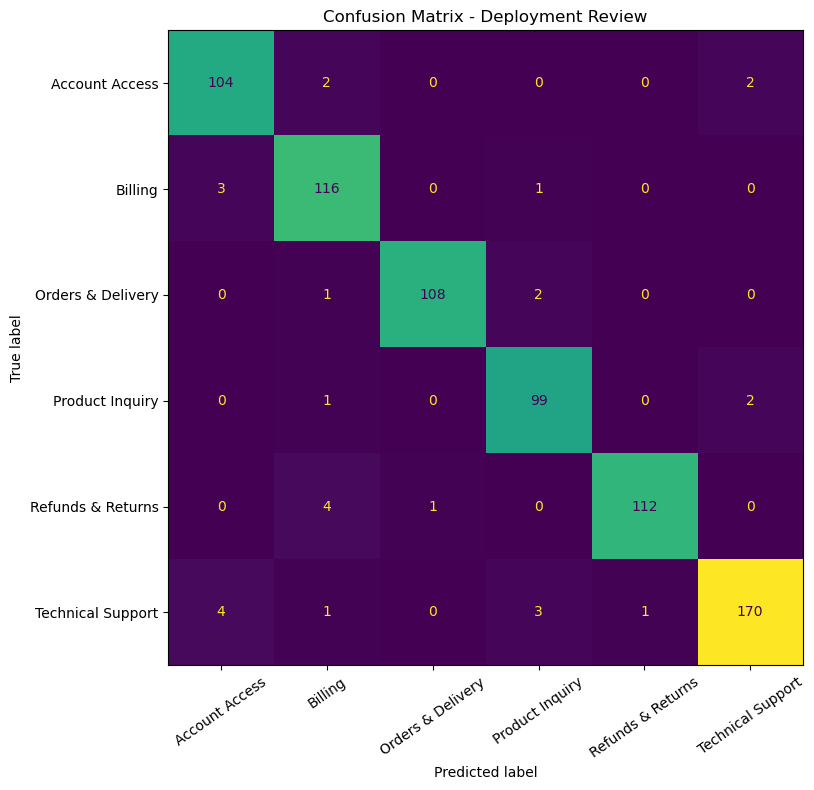

Saved confusion matrix to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\figures\notebook3_confusion_matrix.png


In [32]:
labels_sorted = sorted(y.unique())

cm = confusion_matrix(y_test, predictions_df["predicted_team"], labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=35, colorbar=False)
plt.title("Confusion Matrix - Deployment Review")
plt.tight_layout()

cm_path = FIGURES_DIR / "notebook3_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved confusion matrix to:", cm_path)

## Review misclassifications where available

Misclassified tickets are extremely useful for improving the system.  
They help identify:
- category overlap
- ambiguous wording
- gaps in the dataset design
- opportunities for improved preprocessing or labeling

If there are no misclassifications, that is itself an important observation and may indicate that the synthetic dataset is too easily separable.

In [33]:
misclassified_df = predictions_df[~predictions_df["is_correct"]].copy()

print("Number of misclassified tickets:", len(misclassified_df))

if len(misclassified_df) > 0:
    display(misclassified_df.head(20).reset_index(drop=True))
else:
    print("No misclassifications were found on the current test set.")
    print("This may indicate that the synthetic dataset is overly easy or strongly separable.")

Number of misclassified tickets: 28


,ticket_text,actual_team,predicted_team,is_correct,confidence_score,routing_decision
0,Issue not resolved,Billing,Account Access,False,0.198077,Human review
1,"Problem with recent activity I need help with something. I cannot sign in to my account at the moment. Also, the page is not loading properly and I cannot c...",Account Access,Technical Support,False,0.345040,Human review
2,NEED AN UPDATE ON THIS ISSUE,Orders & Delivery,Product Inquiry,False,0.209353,Human review
3,"Problem with Data Export The export fails halfway through and I do not know why. Also, i need more information before making a decision. I do not know if th...",Technical Support,Product Inquiry,False,0.445643,Human review
4,"Hello, The product arrived damaged and I need help with next steps. Also, the amount shown on the invoice looks wrong. This seems linked to my recent order....",Refunds & Returns,Billing,False,0.370862,Human review
5,"billing issue on my account This was workng before but now it keeps failing. Also, the amount shown on the invoice looks wrong. I would appreciate a quick r...",Technical Support,Billing,False,0.498238,Human review
6,Follow-up on my previous issue,Billing,Account Access,False,0.192831,Human review
7,"URGENT - Need support urgently I need to return the item because it is not as expected. In addition, the invoice does not look right to me. I noticed this a...",Refunds & Returns,Billing,False,0.322014,Human review
8,Follow-up on my previous issue,Billing,Account Access,False,0.192831,Human review
9,Need help with Customer Portal,Account Access,Billing,False,0.319918,Human review


## Identify the most common confusion pairs

Where misclassifications exist, confusion pairs show which classes the model mixes up most often.

Examples of plausible confusion pairs in real support data include:
- Billing vs Refunds & Returns
- Account Access vs Technical Support
- Product Inquiry vs Billing

In [34]:
if len(misclassified_df) > 0:
    confusion_pairs = (
        misclassified_df.groupby(["actual_team", "predicted_team"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    display(confusion_pairs)
else:
    confusion_pairs = pd.DataFrame(columns=["actual_team", "predicted_team", "count"])
    print("No confusion pairs to display because there are no current misclassifications.")

,actual_team,predicted_team,count
0,Technical Support,Account Access,4
1,Refunds & Returns,Billing,4
2,Billing,Account Access,3
3,Technical Support,Product Inquiry,3
4,Account Access,Technical Support,2
5,Account Access,Billing,2
6,Orders & Delivery,Product Inquiry,2
7,Product Inquiry,Technical Support,2
8,Orders & Delivery,Billing,1
9,Billing,Product Inquiry,1


## Inspect top predictive terms for each routed team

For linear models such as Logistic Regression and Linear SVC, the fitted coefficients can be used to identify the most influential terms for each class.

This helps explain:
- what words drive routing decisions
- whether the model is learning meaningful business signals
- whether the dataset contains overly obvious label cues

In [35]:
def get_top_terms_from_linear_pipeline(fitted_pipeline, top_n=15):
    vectorizer = fitted_pipeline.named_steps["tfidf"]
    model = fitted_pipeline.named_steps["model"]

    if not hasattr(model, "coef_"):
        print("Top-term extraction is only available for linear models.")
        return None

    feature_names = np.array(vectorizer.get_feature_names_out())
    classes = model.classes_

    rows = []
    for i, class_name in enumerate(classes):
        top_idx = np.argsort(model.coef_[i])[-top_n:][::-1]
        terms = feature_names[top_idx]
        rows.append({
            "routed_team": class_name,
            "top_terms": ", ".join(terms)
        })

    return pd.DataFrame(rows)

top_terms_df = get_top_terms_from_linear_pipeline(pipeline, top_n=15)

if top_terms_df is not None:
    display(top_terms_df)
    top_terms_path = RESULTS_DIR / "notebook3_top_terms.csv"
    top_terms_df.to_csv(top_terms_path, index=False)
    print("Saved top terms to:", top_terms_path)

,routed_team,top_terms
0,Account Access,"authentication, authentication going, problem involves, locked, appear, appear locked, access, moment involves, locked involves, correct involves, help acce..."
1,Billing,"account involves, payment, incorrectly involves, failed involves, right involves, account related, need review, wrong involves, problem payment, invoice, re..."
2,Orders & Delivery,"order arrived, tracking, tracking updated, updated involves, delay shipment, delay, shipment, update involves, arrived involves, arrived, shipment involves,..."
3,Product Inquiry,"question involves, works involves, setup involves, case involves, decision involves, help explain, explain, morning explain, options, works, help general, g..."
4,Refunds & Returns,"return, refund, update refund, refund involves, order involves, steps involves, money resolved, need money, resolved involves, refnd, money, purchase involv..."
5,Technical Support,"keeps, working keeps, failing involves, failing time, export, breaking involves, complete, api, behaviour product, seeing unexpected, seeing, try, product i..."


Saved top terms to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\notebook3_top_terms.csv


## Flag potentially obvious dataset cues

If top terms include very explicit class markers such as:
- `refund`
- `invoice`
- `password`
- `tracking`
- `crash`

then the model may be benefiting from highly separable synthetic text patterns.

This does not make the model useless, but it does suggest that the dataset should eventually be made harder and more realistic.

In [36]:
obvious_cue_terms = {
    "Billing": ["invoice", "charge", "billing", "payment"],
    "Refunds & Returns": ["refund", "return", "damaged"],
    "Account Access": ["password", "login", "locked", "authentication"],
    "Technical Support": ["error", "crash", "bug", "timeout"],
    "Orders & Delivery": ["delivery", "tracking", "shipment", "package"],
    "Product Inquiry": ["pricing", "feature", "comparison", "compatibility"]
}

cue_check_rows = []

if top_terms_df is not None:
    for _, row in top_terms_df.iterrows():
        team = row["routed_team"]
        terms = [t.strip() for t in row["top_terms"].split(",")]
        obvious_terms_found = [term for term in terms if term in obvious_cue_terms.get(team, [])]

        cue_check_rows.append({
            "routed_team": team,
            "obvious_terms_found": ", ".join(obvious_terms_found) if obvious_terms_found else "None"
        })

cue_check_df = pd.DataFrame(cue_check_rows)
display(cue_check_df)

,routed_team,obvious_terms_found
0,Account Access,"authentication, locked"
1,Billing,"payment, invoice"
2,Orders & Delivery,"tracking, shipment"
3,Product Inquiry,None
4,Refunds & Returns,"return, refund"
5,Technical Support,None


## A deployment-ready prediction function

This helper function allows future notebooks, dashboards, or apps to send raw support ticket text into the pipeline and receive:
- predicted routed team
- confidence score
- routing decision

In [37]:
def predict_ticket_route(ticket_text, fitted_pipeline, review_threshold=0.80):
    ticket_series = pd.Series([ticket_text])

    prediction_output = get_confidence_scores(fitted_pipeline, ticket_series)

    predicted_team = prediction_output["predicted_labels"][0]
    confidence = prediction_output["confidence"][0]

    if pd.isna(confidence):
        decision = "Auto-route"
    else:
        decision = "Auto-route" if confidence >= review_threshold else "Human review"

    return {
        "ticket_text": ticket_text,
        "predicted_team": predicted_team,
        "confidence_score": float(confidence) if not pd.isna(confidence) else np.nan,
        "routing_decision": decision
    }

## Testing the deployment-ready function on new ticket examples

We now simulate incoming support tickets and inspect the routing outputs.  
This mirrors how the logic could later be used inside a Streamlit app or triage dashboard.

In [38]:
sample_tickets = [
    "I was charged twice for my annual plan and need someone to review the invoice.",
    "I cannot reset my password and I am locked out of the customer portal.",
    "The dashboard crashes whenever I try to export my report.",
    "My order still has not arrived and tracking has not updated for days.",
    "I want to return the damaged device and check the status of my refund.",
    "Can you explain the difference between the pro and enterprise pricing plans?"
]

sample_predictions = pd.DataFrame(
    [predict_ticket_route(text, pipeline, review_threshold=REVIEW_THRESHOLD) for text in sample_tickets]
)

display(sample_predictions)

,ticket_text,predicted_team,confidence_score,routing_decision
0,I was charged twice for my annual plan and need someone to review the invoice.,Billing,0.689112,Human review
1,I cannot reset my password and I am locked out of the customer portal.,Account Access,0.653089,Human review
2,The dashboard crashes whenever I try to export my report.,Technical Support,0.758222,Human review
3,My order still has not arrived and tracking has not updated for days.,Orders & Delivery,0.974113,Auto-route
4,I want to return the damaged device and check the status of my refund.,Refunds & Returns,0.845607,Auto-route
5,Can you explain the difference between the pro and enterprise pricing plans?,Product Inquiry,0.771454,Human review


## An operational triage output table

This table represents what a real routing workflow might consume:
- raw ticket text
- actual team
- predicted team
- confidence
- routing decision
- correctness flag

This output can later be connected to:
- a dashboard
- a triage inbox
- a quality review process

In [39]:
triage_output_df = predictions_df.copy()
triage_output_df = triage_output_df.sort_values(
    by=["routing_decision", "confidence_score"],
    ascending=[False, True]
).reset_index(drop=True)

triage_output_path = RESULTS_DIR / "ticket_triage_operational_output.csv"
triage_output_df.to_csv(triage_output_path, index=False)

print("Saved operational triage output to:", triage_output_path)
display(triage_output_df.head(20))

Saved operational triage output to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\ticket_triage_operational_output.csv


,ticket_text,actual_team,predicted_team,is_correct,confidence_score,routing_decision
0,Follow-up on my previous issue,Billing,Account Access,False,0.192831,Human review
1,Follow-up on my previous issue,Billing,Account Access,False,0.192831,Human review
2,Issue not resolved,Billing,Account Access,False,0.198077,Human review
3,NEED AN UPDATE ON THIS ISSUE,Orders & Delivery,Product Inquiry,False,0.209353,Human review
4,Need an update on this issue,Product Inquiry,Product Inquiry,True,0.209353,Human review
5,isue with recent order,Refunds & Returns,Refunds & Returns,True,0.214881,Human review
6,Support request still,Account Access,Billing,False,0.224344,Human review
7,Problem with recent activity,Technical Support,Product Inquiry,False,0.228637,Human review
8,PLEASE REVIEW THIS REQUEST,Orders & Delivery,Billing,False,0.236504,Human review
9,crash on my account,Technical Support,Technical Support,True,0.252599,Human review


## Key observations

The analyses in this notebook help assess whether the routing model is operationally usable.

### Areas reviewed
- prediction confidence
- low-confidence cases
- misclassifications
- top predictive features
- human-review fallback logic

### What these results mean
A model can only be considered deployment-ready if it is not only accurate, but also interpretable and controllable.

### Important interpretation note
If the model shows:
- uniformly high confidence
- no misclassifications
- very obvious top terms by class

then the synthetic dataset may be too easy and should be made more realistic in a future iteration.

## Final conclusion

This notebook moved the ticket routing system from a pure modeling exercise toward a more operational NLP workflow.

### What was completed
- loaded and reused the best saved routing pipeline
- generated confidence-aware predictions
- applied a human-review routing threshold
- inspected low-confidence and misclassified examples
- reviewed top class-specific terms for explainability
- created a deployment-ready ticket prediction function
- exported triage outputs for future application use

### Why this matters
In a real support environment, trustworthy automation requires more than strong metrics.  
It also requires:
- transparency
- fallback control
- reviewability
- practical outputs for downstream operations

This notebook provides that bridge between model performance and operational readiness.

In [40]:
summary_data = {
    "confidence_method": [confidence_output["method"]],
    "review_threshold": [REVIEW_THRESHOLD],
    "auto_route_count": [(predictions_df["routing_decision"] == "Auto-route").sum()],
    "human_review_count": [(predictions_df["routing_decision"] == "Human review").sum()],
    "misclassified_count": [len(misclassified_df)],
    "test_sample_count": [len(predictions_df)]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

summary_path = RESULTS_DIR / "notebook3_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved notebook summary to:", summary_path)

,confidence_method,review_threshold,auto_route_count,human_review_count,misclassified_count,test_sample_count
0,decision_function_softmax,0.8,34,703,28,737


Saved notebook summary to: C:\Users\Owen\Documents\Hertsfordshire\Projects\Automating Support Ticket Routing with NLP\results\notebook3_summary.csv
